# Unified Figure Notebook (Figures 1-5)

This notebook reproduces all figure plotting workflows in one place with **easy-to-edit configuration blocks**.

## How to use
1. Edit the config dictionaries near each figure section.
2. Run cells top-to-bottom once to define helpers.
3. Re-run only the figure section you are tuning.

Optional: enable `GLOBAL_CONFIG["rebuild_intermediate_data"]` to regenerate intermediate CSVs for Figures 1, 3, and 4 from the original data scripts.

In [1]:
from __future__ import annotations

import os
import re
import runpy
import pickle
from pathlib import Path
from typing import Any, Tuple
from itertools import combinations
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import r2_score


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
        if all((candidate / p).exists() for p in ["README.md", "scripts", "outputs", "figures_scripts_notebooks"]):
            return candidate
    raise FileNotFoundError(
        f"Could not find repo root from {here}. Expected pyproject.toml or standard repo markers."
    )


REPO_ROOT = find_repo_root()
FIG_NOTEBOOK_DIR = REPO_ROOT / "figures_scripts_notebooks"

plt.rcParams["figure.dpi"] = 120
sns.set_context("talk")
sns.set_style("whitegrid")

print(f"Repo root: {REPO_ROOT}")

Repo root: /stor/work/Ellington/bioml/zero_shot_analysis


In [2]:
GLOBAL_CONFIG = {
    "save_figures": True,
    "show_figures": True,
    "save_formats": ["png"],
    "png_dpi": 300,
    "rebuild_intermediate_data": False,
}

MODEL_LABELS = {
    "ESM2_650M": "ESM-2 650M",
    "ESM2_3B": "ESM-2 3B",
    "ESMC_600M": "ESMC 600M",
    "ESMC_300M": "ESMC 300M",
    "ESM3_sm_both": "ESM-3 (hybrid)",
    "ESM3_sm_sequence": "ESM-3 (sequence)",
    "ESM3_sm_structure": "ESM-3 (structure)",
    "ISMC_600M": "ISMC 600M",
    "ISMC_300M": "ISMC 300M",
    "ISM_650M": "ISM 650M",
    "ISM2-650M": "ISM 650M",
    "SaProt_650M": "SaProt 650M",
    "AMPLIFY_350M": "AMPLIFY 350M",
    "AMPLIFY_120M": "AMPLIFY 120M",
    "SaProt_650M_AF2": "SaProt 650M (AF2)",
    "ProstT5": "ProstT5",
    "SolubleMPNN": "SolubleMPNN",
    "ProteinMPNN": "ProteinMPNN",
}

MODEL_COLORS = {
    "ESM-2 650M": "black",
    "ESM-2 3B": "black",
    "ESMC 600M": "black",
    "ESMC 300M": "black",
    "ESM-3 (hybrid)": "tab:blue",
    "ESM-3 (sequence)": "black",
    "ESM-3 (structure)": "tab:red",
    "ISMC 600M": "tab:blue",
    "ISMC 300M": "tab:blue",
    "ISM 650M": "tab:blue",
    "SaProt 650M": "tab:blue",
    "AMPLIFY 350M": "black",
    "AMPLIFY 120M": "black",
    "SaProt 650M (AF2)": "tab:blue",
    "ProstT5": "tab:red",
    "SolubleMPNN": "tab:red",
    "ProteinMPNN": "tab:red",
}


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def save_figure(fig: plt.Figure, out_base: Path, cfg: dict):
    if not cfg["save_figures"]:
        return
    ensure_dir(out_base.parent)
    for ext in cfg["save_formats"]:
        if ext == "png":
            fig.savefig(out_base.with_suffix(".png"), dpi=cfg["png_dpi"], bbox_inches="tight")
        else:
            fig.savefig(out_base.with_suffix(f".{ext}"), bbox_inches="tight")


def maybe_rebuild_intermediate_data():
    if not GLOBAL_CONFIG["rebuild_intermediate_data"]:
        return
    scripts = [
        FIG_NOTEBOOK_DIR / "figure1_scripts" / "make_figure1_plot_data.py",
        FIG_NOTEBOOK_DIR / "figure3_scripts" / "make_figure3_plot_data.py",
        FIG_NOTEBOOK_DIR / "figure4_scripts" / "make_figure4_plot_data.py",
    ]
    for script in scripts:
        print(f"Running data script: {script}")
        cwd = Path.cwd()
        try:
            os.chdir(script.parent)
            runpy.run_path(str(script), run_name="__main__")
        finally:
            os.chdir(cwd)


maybe_rebuild_intermediate_data()

## Figure 1
Side-by-side model comparison and inter-model paired comparisons.

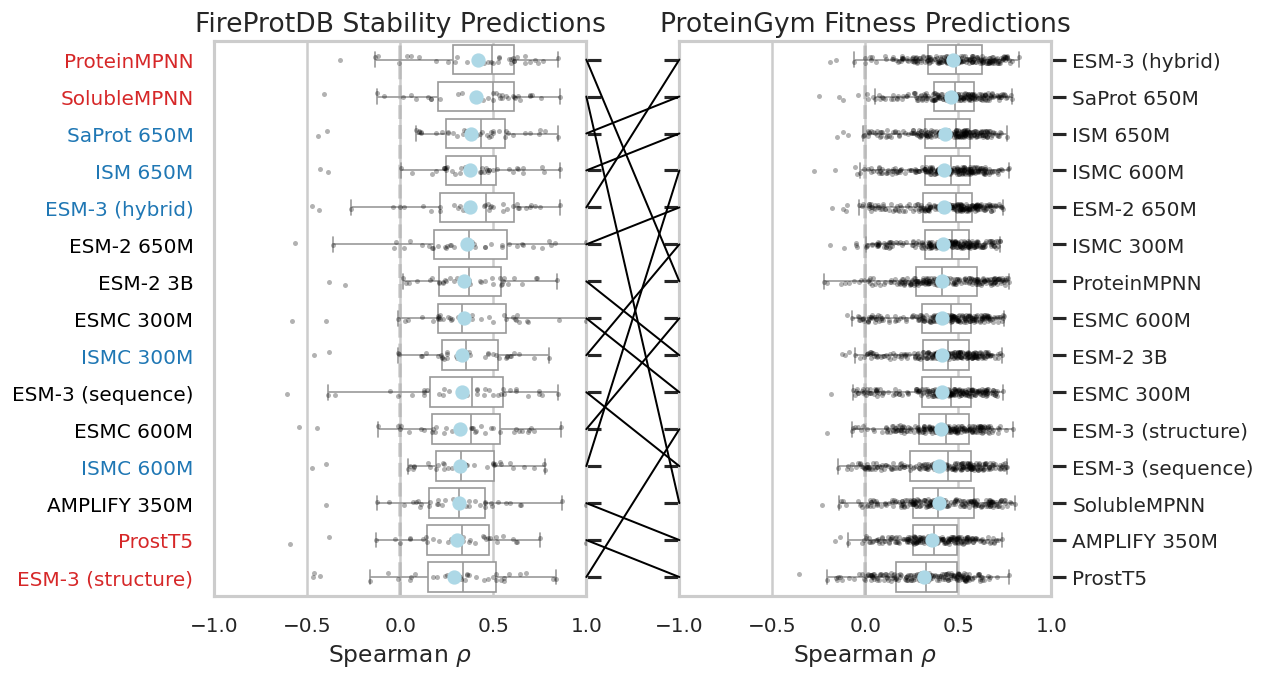

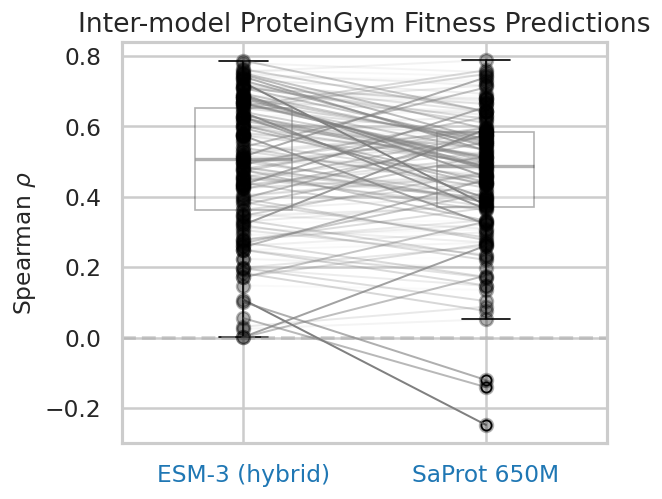

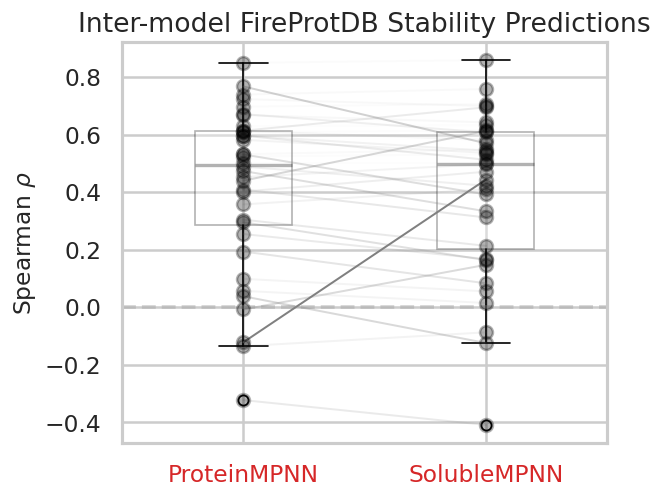

In [ ]:
FIG1 = {
    "fpdb_csv": REPO_ROOT / "outputs/csvs/fig1_fpdb_comparison_plot.csv",
    "proteingym_csv": REPO_ROOT / "outputs/csvs/fig1_pg_comparison_plot.csv",
    "out_dir": REPO_ROOT / "images/figure1",
    "comparison_figsize": (9, 6),
    "comparison_wspace": 0.25,
    "xlim": (-1, 1),
    "metric_col": "spearman_rho",
    "intermodel_pairs": [
        ("ESM-3 (hybrid)", "SaProt 650M", "proteingym"),
        ("ProteinMPNN", "SolubleMPNN", "fireprotdb"),
    ],
}


def fig1_tidy_df(df: pd.DataFrame, metric_col: str):
    pivot_df = df.groupby(["protein", "model"])[metric_col].max().unstack()
    rank_df = pivot_df.rank(axis=1, ascending=False)
    _ = rank_df.mean().sort_values()
    model_order = df.groupby("model")[metric_col].mean().sort_values(ascending=False).index.tolist()
    out = df.copy()
    out["model"] = pd.Categorical(out["model"], categories=model_order, ordered=True)
    out = out.sort_values("model")
    return out, model_order


def plot_figure1_comparison(fpdb_metrics: pd.DataFrame, gym_metrics: pd.DataFrame, cfg: dict):
    fpdb_metrics = fpdb_metrics.copy()
    gym_metrics = gym_metrics.copy()
    fpdb_metrics["model"] = fpdb_metrics["model"].replace(MODEL_LABELS)
    gym_metrics["model"] = gym_metrics["model"].replace(MODEL_LABELS)

    metric_col = cfg["metric_col"]
    df1, order1 = fig1_tidy_df(fpdb_metrics, metric_col)
    df2, order2 = fig1_tidy_df(gym_metrics, metric_col)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=cfg["comparison_figsize"], sharey=False)
    fig.subplots_adjust(wspace=cfg["comparison_wspace"])

    for ax, df, order, title, left in [
        (ax1, df1, order1, "FireProtDB Stability Predictions", True),
        (ax2, df2, order2, "ProteinGym Fitness Predictions", False),
    ]:
        ax.axvline(x=0, color="darkgrey", linestyle="--", alpha=0.5)
        sns.boxplot(data=df, x=metric_col, y="model", order=order, color="white", fliersize=0, linewidth=1, ax=ax)
        means = df.groupby("model", observed=False)[metric_col].mean()
        for i, model in enumerate(order):
            ax.scatter(means[model], i, color="lightblue", marker="o", s=50, zorder=10)
        sns.stripplot(data=df, x=metric_col, y="model", order=order, color="black", size=3, jitter=True, alpha=0.3, ax=ax)

        for label in ax.get_yticklabels():
            name = label.get_text()
            if name in MODEL_COLORS:
                label.set_color(MODEL_COLORS[name])

        ax.set_ylabel("")
        ax.set_xlabel("Spearman $\\rho$", fontsize=14)
        ax.set_xlim(*cfg["xlim"])
        ax.set_title(title, fontsize=16)
        ax.tick_params(labelsize=12)

        if left:
            ax.tick_params(right=True, labelright=False)
        else:
            ax.yaxis.tick_right()
            ax.yaxis.set_label_position("right")
            ax.tick_params(left=True, labelleft=False)

    for model in order1:
        if model not in order2:
            continue
        y1 = order1.index(model)
        y2 = order2.index(model)
        p1 = ax1.transData.transform((cfg["xlim"][1], y1))
        p2 = ax2.transData.transform((cfg["xlim"][0], y2))
        p1f = fig.transFigure.inverted().transform(p1)
        p2f = fig.transFigure.inverted().transform(p2)
        line = plt.Line2D([p1f[0], p2f[0]], [p1f[1], p2f[1]], transform=fig.transFigure, color="black", alpha=1.0, linewidth=1.2, zorder=1)
        fig.add_artist(line)

    save_figure(fig, cfg["out_dir"] / "comparison_plot", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


def plot_figure1_intermodel(fpdb_metrics: pd.DataFrame, gym_metrics: pd.DataFrame, model0: str, model1: str, database: str, cfg: dict):
    fpdb_metrics = fpdb_metrics.copy()
    gym_metrics = gym_metrics.copy()
    fpdb_metrics["model"] = fpdb_metrics["model"].replace(MODEL_LABELS)
    gym_metrics["model"] = gym_metrics["model"].replace(MODEL_LABELS)

    metric_col = cfg["metric_col"]
    if database == "fireprotdb":
        group0 = fpdb_metrics[fpdb_metrics["model"] == model0].groupby("protein")[metric_col].mean().dropna()
        group1 = fpdb_metrics[fpdb_metrics["model"] == model1].groupby("protein")[metric_col].mean().dropna()
        title = "Inter-model FireProtDB Stability Predictions"
        out_name = f"inter-model_comparison_plot_fireprotdb_{model0.replace(' ', '_')}_{model1.replace(' ', '_')}"
    else:
        group0 = gym_metrics[gym_metrics["model"] == model0].groupby("protein")[metric_col].mean().dropna()
        group1 = gym_metrics[gym_metrics["model"] == model1].groupby("protein")[metric_col].mean().dropna()
        title = "Inter-model ProteinGym Fitness Predictions"
        out_name = f"inter-model_comparison_plot_proteingym_{model0.replace(' ', '_')}_{model1.replace(' ', '_')}"

    common = group0.index.intersection(group1.index)
    group0 = group0.loc[common]
    group1 = group1.loc[common]

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    pos0, pos1 = 1, 2
    ax.boxplot(group0, positions=[pos0], widths=0.4, patch_artist=True, boxprops=dict(facecolor="white", alpha=0.3), medianprops=dict(color="black", linewidth=2, alpha=0.3))
    ax.boxplot(group1, positions=[pos1], widths=0.4, patch_artist=True, boxprops=dict(facecolor="white", alpha=0.3), medianprops=dict(color="black", linewidth=2, alpha=0.3))

    diffs = np.abs(group1 - group0)
    diff_min, diff_max = diffs.min(), diffs.max()
    denom = max(diff_max - diff_min, 1e-9)
    for cat in common:
        y0 = float(group0.loc[cat])
        y1 = float(group1.loc[cat])
        alpha = float(np.clip(0.01 + (1.0 - 0.01) * (diffs.loc[cat] - diff_min) / denom, 0.01, 1.0))
        ax.scatter([pos0], [y0], color="black", zorder=5, alpha=0.3, s=60)
        ax.scatter([pos1], [y1], color="black", zorder=5, alpha=0.3, s=60)
        ax.plot([pos0, pos1], [y0, y1], color="gray", alpha=alpha, linewidth=1.2, zorder=4)

    ax.set_xticks([pos0, pos1])
    ax.set_xticklabels([model0, model1], fontsize=14)
    for ticklabel, color in zip(ax.get_xticklabels(), [MODEL_COLORS.get(model0, "black"), MODEL_COLORS.get(model1, "black")]):
        ticklabel.set_color(color)

    ax.set_ylabel("Spearman $\\rho$", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0.5, 2.5)
    ax.tick_params(labelsize=14)
    ax.axhline(y=0, color="darkgrey", linestyle="--", alpha=0.5)
    plt.tight_layout()

    # save_figure(fig, cfg["out_dir"] / out_name, GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


fpdb_metrics = pd.read_csv(FIG1["fpdb_csv"])
gym_metrics = pd.read_csv(FIG1["proteingym_csv"])
ensure_dir(FIG1["out_dir"])

plot_figure1_comparison(fpdb_metrics, gym_metrics, FIG1)
for m0, m1, db in FIG1["intermodel_pairs"]:
    plot_figure1_intermodel(fpdb_metrics, gym_metrics, m0, m1, db, FIG1)

## Figure 2
Inter-phenotype and inter-experimenter correlation plots from ProteinGym substitution groups.

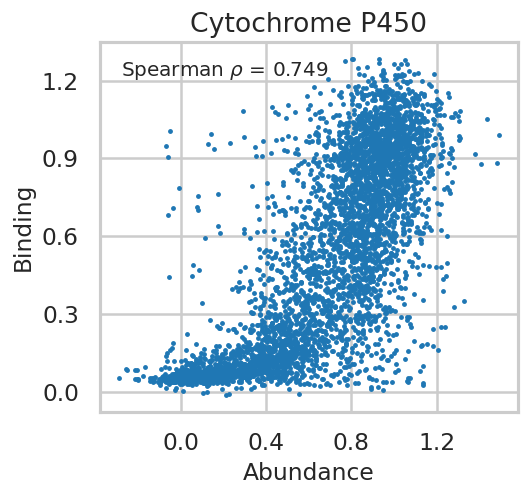

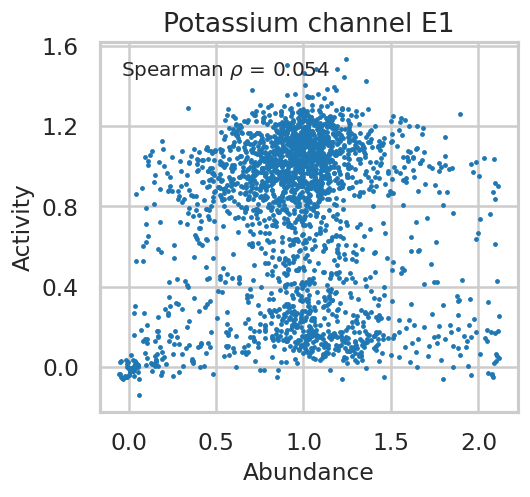

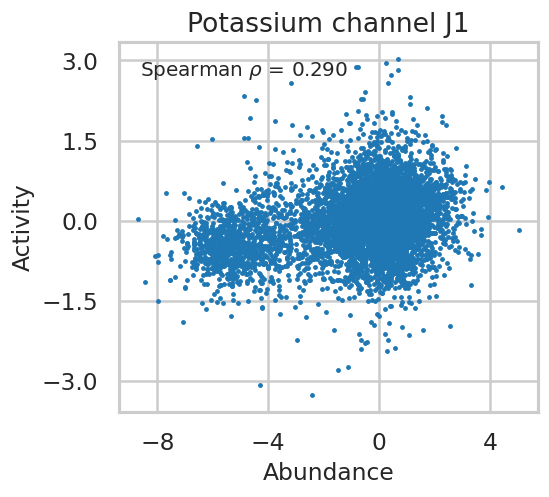

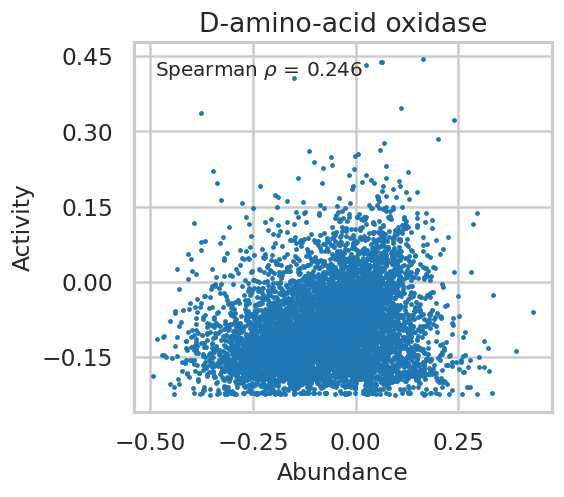

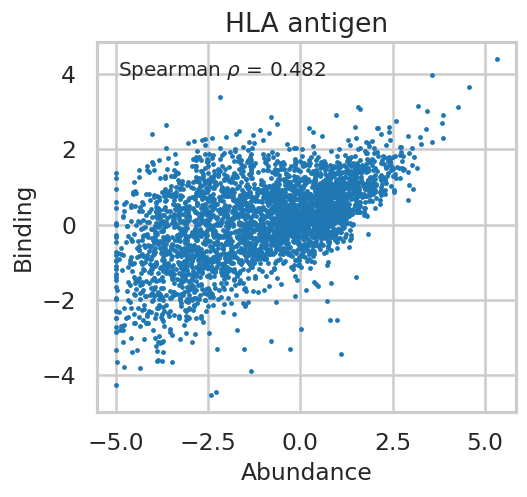

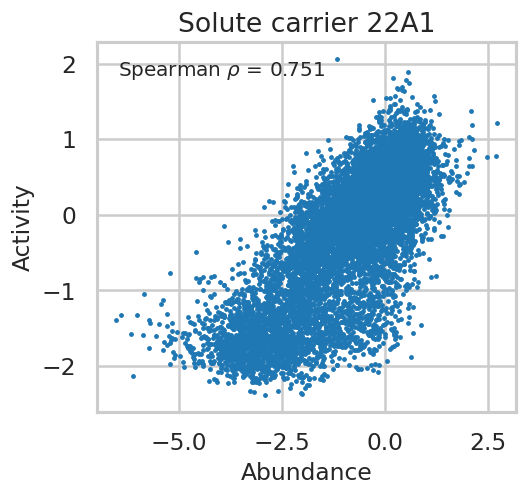

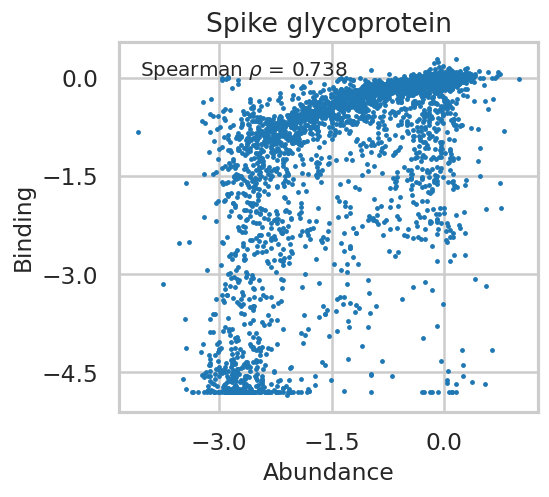

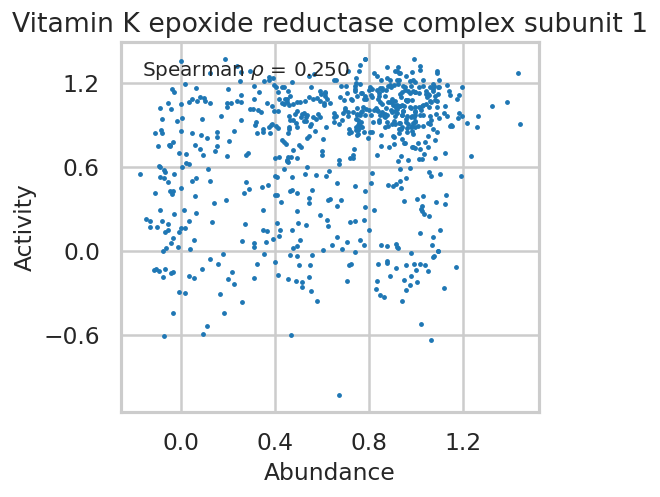

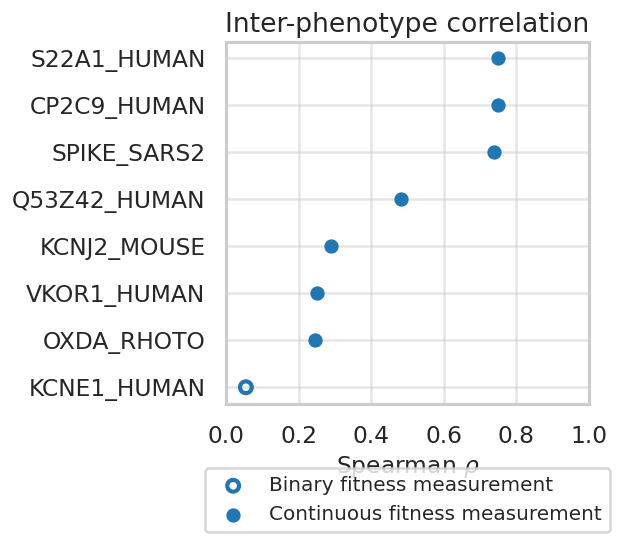

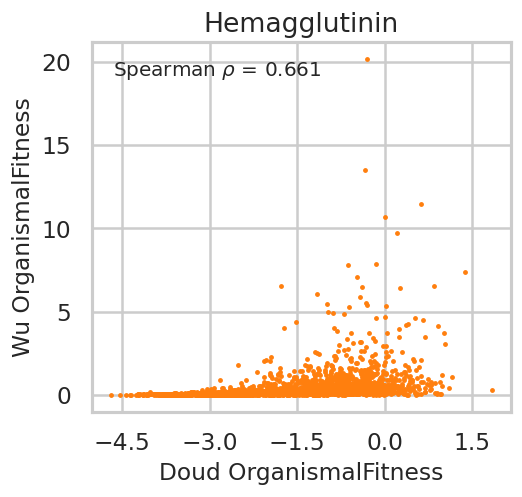

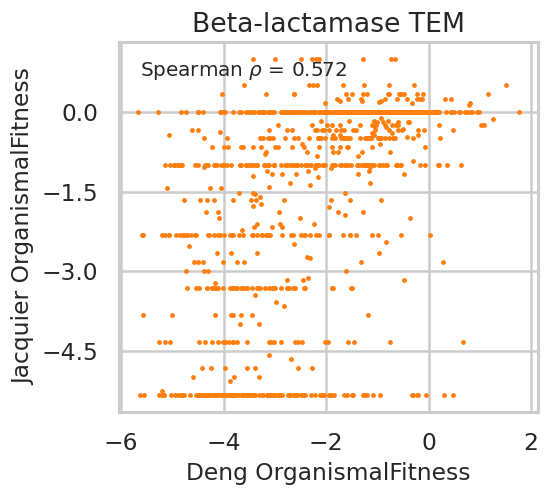

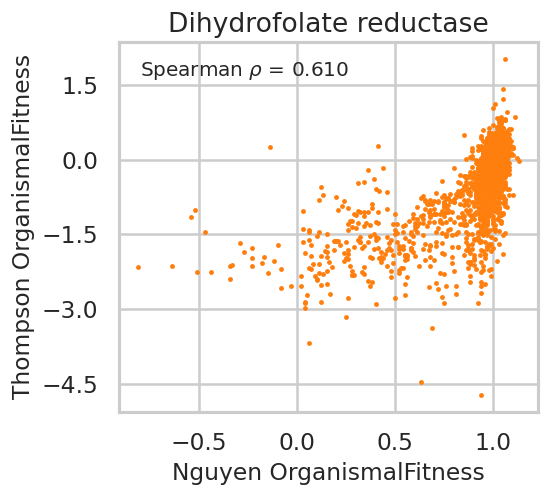

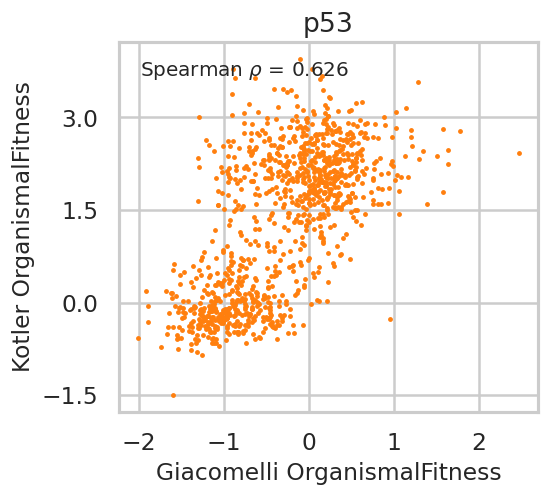

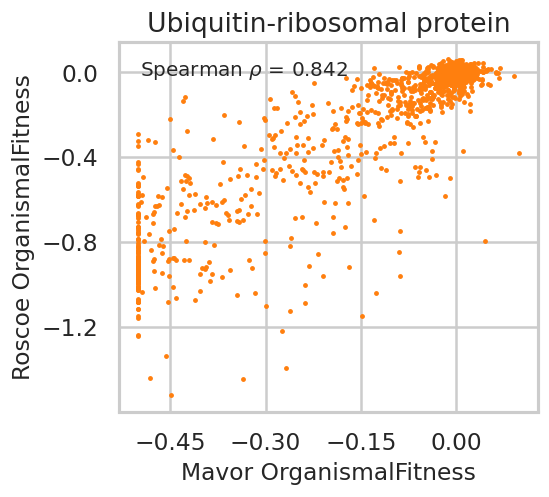

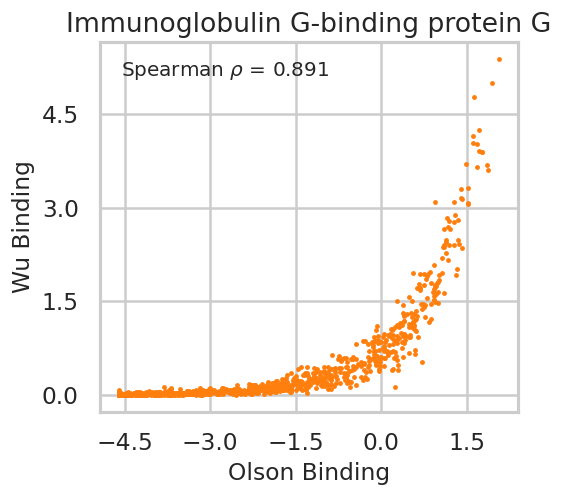

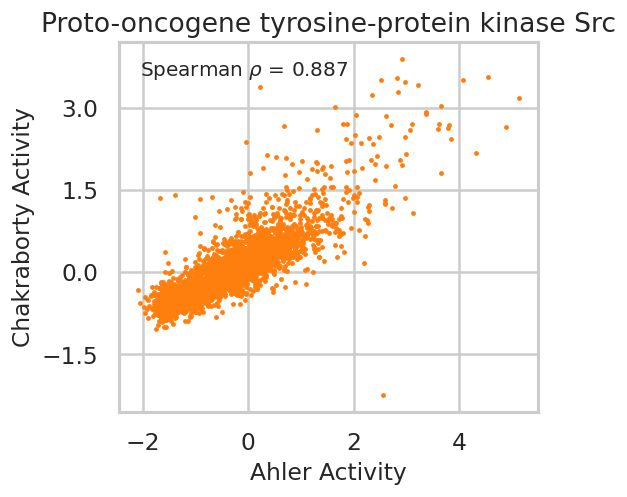

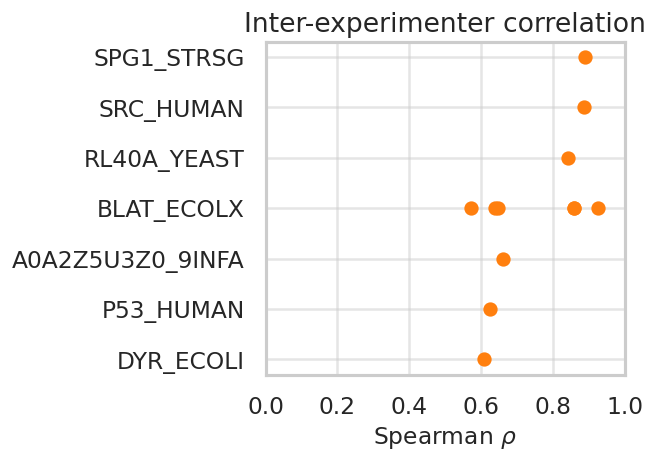

In [11]:
FIG2 = {
    "groups_tsv": REPO_ROOT / "data/proteingym_data/DMS_substitutions_groups.tsv",
    "proteingym_csv_dir": REPO_ROOT / "data/proteingym_data/DMS_ProteinGym_substitutions",
    "out_dir": REPO_ROOT / "images/figure2",
    "group1_color": "#1f77b4",
    "group2_color": "#ff7f0e",
}


def figure2_dataset_analysis_plots(g_df: pd.DataFrame, csv_dir: Path, png_dir: Path, group: int, cfg: dict):
    def linear_regression(x, y):
        pair_df = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
        if pair_df.shape[0] < 2:
            return np.nan, np.nan

        x_clean = pair_df["x"].to_numpy(dtype=float)
        y_clean = pair_df["y"].to_numpy(dtype=float)

        m, b = np.polyfit(x_clean, y_clean, 1)
        y_pred = m * x_clean + b
        pearson_r2 = r2_score(y_clean, y_pred)
        spearman_rho, _ = spearmanr(x_clean, y_clean)
        return pearson_r2, spearman_rho

    color = cfg["group1_color"] if group == 1 else cfg["group2_color"]
    global_stats = []

    for _, row in g_df.iterrows():
        if not isinstance(row["group_str"], str) or not row["group_str"]:
            continue
        exps = row["group_str"].split(",")
        protein_data, selections = [], []

        for exp in exps:
            if group == 1:
                selection = exp.split(":")[1]
            elif group == 2:
                s = exp.split(":")
                selection = f"{s[0].split('_')[2]}_{s[1]}"
            else:
                raise ValueError("group must be 1 or 2")

            selections.append(selection)
            csv_path = csv_dir / exp.split(":")[0]
            exp_data = pd.read_csv(csv_path)[["mutant", "DMS_score"]].rename(columns={"DMS_score": selection})
            protein_data.append(exp_data)

        protein_data = reduce(lambda left, right: pd.merge(left, right, on="mutant", how="inner"), protein_data)

        pair_stats = []
        for a, b in combinations(selections, 2):
            x, y = (protein_data[b], protein_data[a]) if b == "Abundance" else (protein_data[a], protein_data[b])
            pearson_r2, spearman_rho = linear_regression(x, y)
            if np.isnan(pearson_r2) or np.isnan(spearman_rho):
                continue
            pair_stats.append({"a": a, "b": b, "pearson": pearson_r2, "spearman_rho": spearman_rho})

        if not pair_stats:
            continue

        pair_df = pd.DataFrame(pair_stats)
        worst = pair_df.loc[pair_df["pearson"].idxmin()]
        a, b = worst["a"], worst["b"]
        pltx, plty = (b, a) if b == "Abundance" else (a, b)

        fig, ax = plt.subplots(figsize=(4.5, 4))
        ax.scatter(protein_data[pltx], protein_data[plty], s=2, c=color)

        if group == 2:
            pltx = f"{pltx.split('_')[0]} {pltx.split('_')[1]}"
            plty = f"{plty.split('_')[0]} {plty.split('_')[1]}"

        ax.set_title(f"{row['name']}", fontsize=16)
        ax.set_xlabel(pltx, fontsize=14)
        ax.set_ylabel(plty, fontsize=14)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
        ax.tick_params(axis="both", labelsize=14)
        ax.text(0.05, 0.95, f"Spearman $\\rho$ = {worst['spearman_rho']:.3f}", transform=ax.transAxes, verticalalignment="top", fontsize=12)

        save_figure(fig, png_dir / f"{row['UniProt_ID']}_spearmanrho", GLOBAL_CONFIG)
        if GLOBAL_CONFIG["show_figures"]:
            plt.show()
        else:
            plt.close(fig)

        global_stats.append({
            "UniProt_ID": row["UniProt_ID"],
            "all_spearman": pair_df["spearman_rho"],
            "mean_spearman": pair_df["spearman_rho"].mean(),
        })

    if not global_stats:
        print(f"No valid pairwise comparisons found for group {group}; skipping summary plot.")
        return

    stats_df = pd.DataFrame(global_stats).sort_values(["mean_spearman"])
    y = np.arange(len(stats_df))

    if group == 1:
        fig, ax = plt.subplots(figsize=(5.5, 5.0))
        hollow = {"KCNE1_HUMAN"}
    else:
        fig, ax = plt.subplots(figsize=(5.8, 4.2))
        hollow = set()

    ax.set_yticks(y)
    ax.set_yticklabels(stats_df["UniProt_ID"], fontsize=14)

    for i, values in enumerate(stats_df["all_spearman"]):
        uniprot = stats_df["UniProt_ID"].iloc[i]
        if uniprot in hollow:
            ax.scatter(values, np.full(len(values), y[i]), facecolors="none", edgecolors=color, s=50, linewidths=2.5)
        else:
            ax.scatter(values, np.full(len(values), y[i]), color=color, s=50)

    ax.set_xlim(0, 1)
    ax.set_xlabel("Spearman $\\rho$", fontsize=14)
    ax.tick_params(labelsize=14)
    ax.grid(alpha=0.5)

    if group == 1:
        ax.set_title("Inter-phenotype correlation", fontsize=16)
        legend_elements = [
            plt.scatter([], [], facecolors="none", edgecolors=color, s=50, linewidths=2.5, label="Binary fitness measurement"),
            plt.scatter([], [], color=color, s=50, label="Continuous fitness measurement"),
        ]
        ax.legend(handles=legend_elements, fontsize=12, loc="upper center", bbox_to_anchor=(0.5, -0.15))
        out_name = "interphenotype_group1_rho-scatterplot"
    else:
        ax.set_title("Inter-experimenter correlation", fontsize=16)
        out_name = "interexperimenter_group2_rho-scatterplot"

    fig.tight_layout()
    save_figure(fig, png_dir / out_name, GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


groups = pd.read_csv(FIG2["groups_tsv"], sep="\t")
interphenotype_g1_df = groups[groups["group1_member"] == 1].rename(columns={"group1_str": "group_str"})
interexperimenter_g2_df = groups[groups["group2_member"] == 1].rename(columns={"group2_str": "group_str"})

interphenotype_g1_dir = ensure_dir(FIG2["out_dir"] / "interphenotype_g1")
interexperimenter_g2_dir = ensure_dir(FIG2["out_dir"] / "interexperimeter_g2")

figure2_dataset_analysis_plots(interphenotype_g1_df, FIG2["proteingym_csv_dir"], interphenotype_g1_dir, group=1, cfg=FIG2)
figure2_dataset_analysis_plots(interexperimenter_g2_df, FIG2["proteingym_csv_dir"], interexperimenter_g2_dir, group=2, cfg=FIG2)

## Figure 3
Inter-phenotype and inter-experimenter model-level summaries.

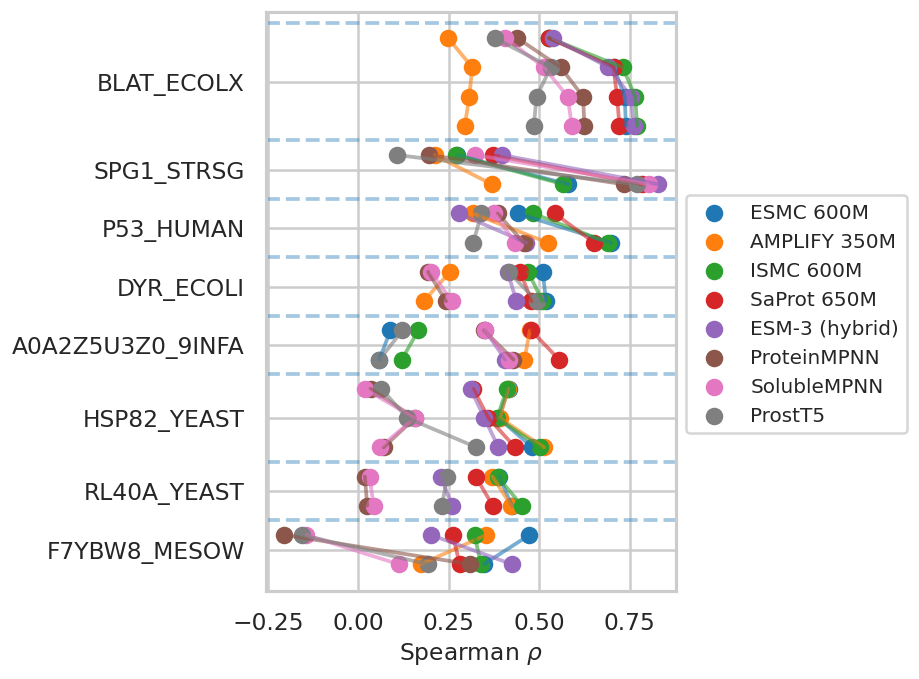

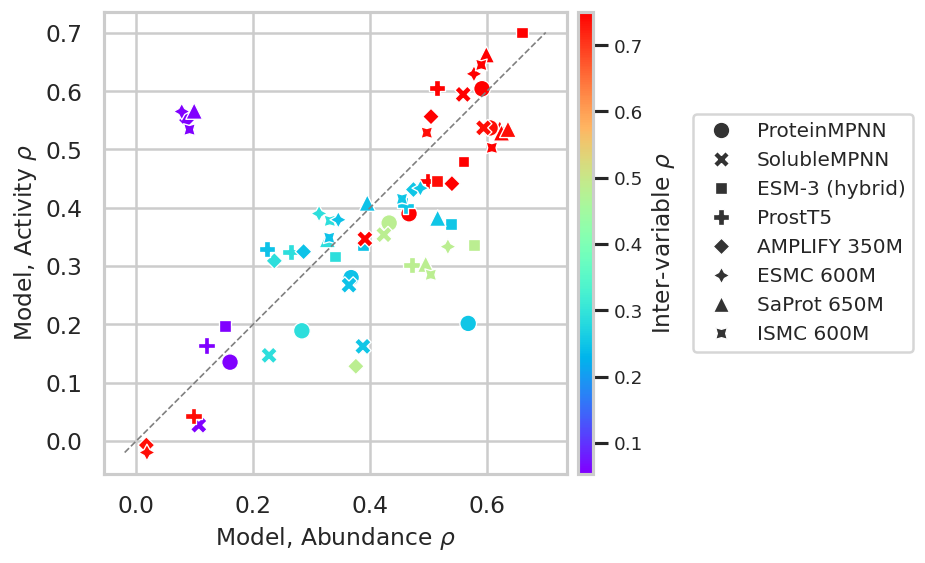

In [5]:
FIG3 = {
    "interphenotype_csv": REPO_ROOT / "outputs/csvs/figure3_interphenotype_g1.csv",
    "interexperimenter_csv": REPO_ROOT / "outputs/csvs/figure3_interexperimenter_g2_uncontrolled.csv",
    "out_dir": REPO_ROOT / "images/figure3",
    "interphenotype_palette": "rainbow",
}


def plot_figure3_interexperimenter(interexperimenter: pd.DataFrame, cfg: dict):
    fig, ax = plt.subplots(figsize=(8, 6))

    score_cols = [c for c in interexperimenter.columns if c != "UniProt_ID"]
    interexperimenter = interexperimenter.dropna(subset=score_cols, how="all").copy()
    if interexperimenter.empty:
        print("No inter-experimenter rows with model scores. Skipping Figure 3A plot.")
        return

    colors = plt.cm.tab10(range(len(score_cols)))
    labeled = {col: False for col in score_cols}

    group_means = (interexperimenter.groupby("UniProt_ID")[score_cols].mean().mean(axis=1).sort_values())
    col_order = group_means.index.tolist()

    offset = 0
    ytick_positions, ytick_labels = [], []
    for group in col_order:
        if group not in interexperimenter["UniProt_ID"].values:
            continue
        gdf = interexperimenter[interexperimenter["UniProt_ID"] == group].sort_index()
        n = len(gdf)
        y = np.arange(n) + offset

        for i, col in enumerate(score_cols):
            color = colors[i]
            ax.plot(gdf[col], y, linestyle="-", alpha=0.6, color=color)
            ax.scatter(gdf[col], y, label=col if not labeled[col] else None, color=color)
            labeled[col] = True

        ytick_positions.append(y.mean())
        ytick_labels.append(group)
        ax.axhline(offset + n - 0.5, linestyle="--", alpha=0.4)
        offset += n

    ax.set_xlabel("Spearman $\\rho$", fontsize=14)
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels(ytick_labels, fontsize=14)
    ax.tick_params(axis="x", labelsize=14)

    handles, labels = ax.get_legend_handles_labels()
    new_labels = [MODEL_LABELS.get(l, l) for l in labels]
    ax.legend(handles, new_labels, bbox_to_anchor=(1, 0.7), loc="upper left", fontsize=12)

    fig.tight_layout()
    save_figure(fig, cfg["out_dir"] / "figure3_interexperimenter", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


def plot_figure3_interphenotype(interphenotype: pd.DataFrame, cfg: dict):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(data=interphenotype, x="expression_rs", y="selection_rs", palette=cfg["interphenotype_palette"], hue="variable_rs", style="model", s=100, ax=ax)

    handles, labels = ax.get_legend_handles_labels()
    style_start = labels.index("model") + 1
    shape_handles = handles[style_start:]
    shape_labels = [MODEL_LABELS.get(l, l) for l in labels[style_start:]]
    ax.legend(shape_handles, shape_labels, bbox_to_anchor=(1.25, 0.8), loc="upper left", fontsize=12, title_fontsize=14)

    norm = mcolors.Normalize(vmin=interphenotype["variable_rs"].min(), vmax=interphenotype["variable_rs"].max())
    sm = cm.ScalarMappable(cmap=cfg["interphenotype_palette"], norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30)
    cbar.set_label("Inter-variable $\\rho$", fontsize=14)
    cbar.ax.tick_params(labelsize=11)

    xmin = min(interphenotype["expression_rs"].min(), interphenotype["selection_rs"].min())
    xmax = max(interphenotype["expression_rs"].max(), interphenotype["selection_rs"].max())
    ax.plot([xmin, xmax], [xmin, xmax], color="gray", linestyle="--", linewidth=1)

    ax.set_xlabel("Model, Abundance $\\rho$", fontsize=14)
    ax.set_ylabel("Model, Activity $\\rho$", fontsize=14)
    ax.tick_params(labelsize=14)

    save_figure(fig, cfg["out_dir"] / "figure3_interphenotype", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


ensure_dir(FIG3["out_dir"])
interphenotype_df = pd.read_csv(FIG3["interphenotype_csv"])
interexperimenter_df = pd.read_csv(FIG3["interexperimenter_csv"])
plot_figure3_interexperimenter(interexperimenter_df, FIG3)
plot_figure3_interphenotype(interphenotype_df, FIG3)

## Shared Mutation Utilities (Figures 4-5)

In [20]:
class ProteinMutationModel:
    AMINO_ACIDS = ["A","R","N","D","C","Q","E","G","H","I","L","K","M","F","P","S","T","W","Y","V"]

    def __init__(self, temperature: float = 1.0, eps: float = 1e-12):
        self.temperature = temperature
        self.eps = eps
        self.probs_long = None
        self.entropy_df = None
        self.data = None

    @staticmethod
    def softmax(x, axis=-1, temperature=1.0):
        if temperature <= 0:
            raise ValueError("Temperature must be positive.")
        x_scaled = x / temperature
        e_x = np.exp(x_scaled - np.max(x_scaled, axis=axis, keepdims=True))
        return e_x / np.sum(e_x, axis=axis, keepdims=True)

    @staticmethod
    def entropy(prob_dist):
        prob_dist = np.asarray(prob_dist)
        prob_dist = prob_dist[prob_dist > 0]
        return -np.sum(prob_dist * np.log2(prob_dist))

    @staticmethod
    def parse_mutations(mutation_string: Any) -> Tuple[Any, int, str, str]:
        if pd.isna(mutation_string) or not isinstance(mutation_string, str):
            return [], 0, "", ""

        muts = mutation_string.split(":")
        pattern = re.compile(r"([A-Za-z])(\d+)([A-Za-z])")
        indices, wt, mut = [], "", ""

        for m in muts:
            match = pattern.search(m)
            if match:
                wt += match.group(1)
                mut += match.group(3)
                indices.append(int(match.group(2)))

        if len(indices) == 1:
            return indices[0], 1, wt, mut
        return indices, len(indices), wt, mut

    def load_pickle(self, pkl_path: Path | str, protein_id: str):
        with open(pkl_path, "rb") as f:
            pkldata = pickle.load(f)

        for k, v in pkldata.items():
            if protein_id in k:
                indices = [int(x) for x in k.split("indices_")[-1].split("_")]
                probs = self.softmax(v, temperature=self.temperature)
                df = pd.DataFrame(probs, index=indices, columns=self.AMINO_ACIDS)
                self.probs_long = df.stack().reset_index().rename(columns={"level_0": "index", "level_1": "amino_acid", 0: "prob"})
                return

        raise ValueError(f"Protein ID '{protein_id}' not found in pickle.")

    def compute_entropy(self):
        self.entropy_df = self.probs_long.groupby("index")["prob"].apply(self.entropy).reset_index(name="entropy")

    def load_experiment(self, csv_path: Path | str):
        exp = pd.read_csv(csv_path)
        exp[["index", "number_mut", "wt", "mut"]] = exp["mutant"].apply(lambda x: pd.Series(self.parse_mutations(x)))
        self.exp_df = exp[exp["number_mut"] == 1].reset_index(drop=True)

    def build_dataset(self):
        probs = self.probs_long.copy()
        exp_df = self.exp_df.copy()

        probs["prob"] = probs["prob"].astype("float64")
        probs = probs.sort_values(["index", "prob"], ascending=[True, False])
        probs["rank"] = probs.groupby("index")["prob"].rank(method="first", ascending=False)

        wt = exp_df[["index", "wt"]].drop_duplicates()
        wt_prob = pd.merge(wt, probs, left_on=["index", "wt"], right_on=["index", "amino_acid"]).rename(columns={"prob": "wt_prob"})[["index", "wt_prob"]]
        wt_rank = pd.merge(wt, probs, left_on=["index", "wt"], right_on=["index", "amino_acid"]).rename(columns={"rank": "wt_rank"})[["index", "wt_rank"]]

        exp = pd.merge(exp_df, probs, left_on=["index", "mut"], right_on=["index", "amino_acid"]).rename(columns={"prob": "mut_prob", "rank": "mut_rank"})
        exp = exp.merge(wt_prob, on="index").merge(wt_rank, on="index")

        if self.entropy_df is not None:
            exp = exp.merge(self.entropy_df, on="index")

        exp = exp.rename(columns={"DMS_score": "exp"})
        exp["log_odds"] = np.log(exp["mut_prob"].clip(self.eps)) - np.log(exp["wt_prob"].clip(self.eps))
        self.data = exp.reset_index(drop=True)

    def spearman(self, column: str = "exp", subsetting: dict | None = None, score_col: str = "log_odds"):
        if self.data is None:
            raise ValueError("Data not built yet. Run build_dataset() first.")

        df = self.data.copy()
        if subsetting is not None:
            for k, v in subsetting.items():
                if v["min_val"] is not None:
                    df = df[df[k] >= v["min_val"]]
                if v["max_val"] is not None:
                    df = df[df[k] <= v["max_val"]]

        if df.shape[0] < 2:
            return np.nan
        return spearmanr(df[column], df[score_col]).correlation


def pull_probs(mutation: str, preds: np.ndarray, preds_name: str):
    amino_acids = ["A","R","N","D","C","Q","E","G","H","I","L","K","M","F","P","S","T","W","Y","V"]

    wt_aa = mutation[0]
    mut_aa = mutation[-1]
    prot_index = mutation[1:-1]

    array_index = preds_name.split(".indices_")[-1].split("_")
    array_index = array_index.index(prot_index)

    pred = preds[array_index]
    probs = ProteinMutationModel.softmax(pred)

    wt_prob = probs[amino_acids.index(wt_aa)]
    mut_prob = probs[amino_acids.index(mut_aa)]
    log_odds = np.log(mut_prob / wt_prob)

    ent_probs = probs[probs > 0]
    entropy = -np.sum(ent_probs * np.log2(ent_probs))

    return wt_prob, mut_prob, log_odds, entropy

## Figure 4
Fitness class scatter and density views.

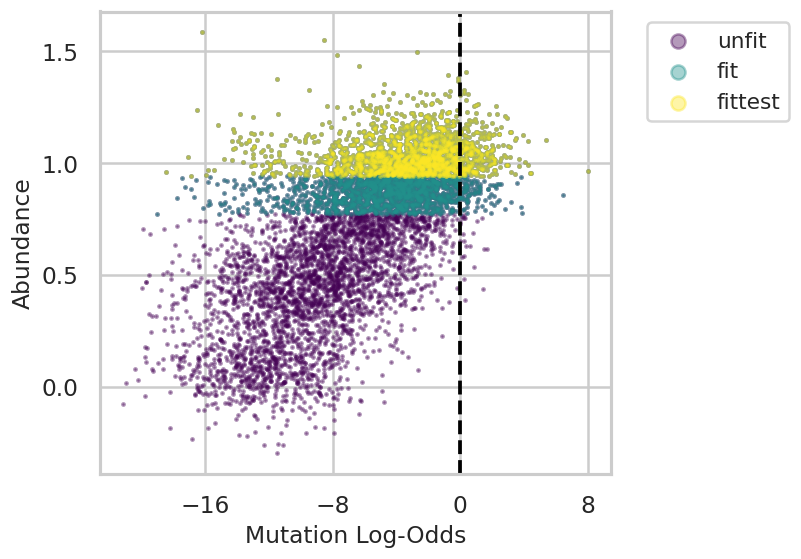

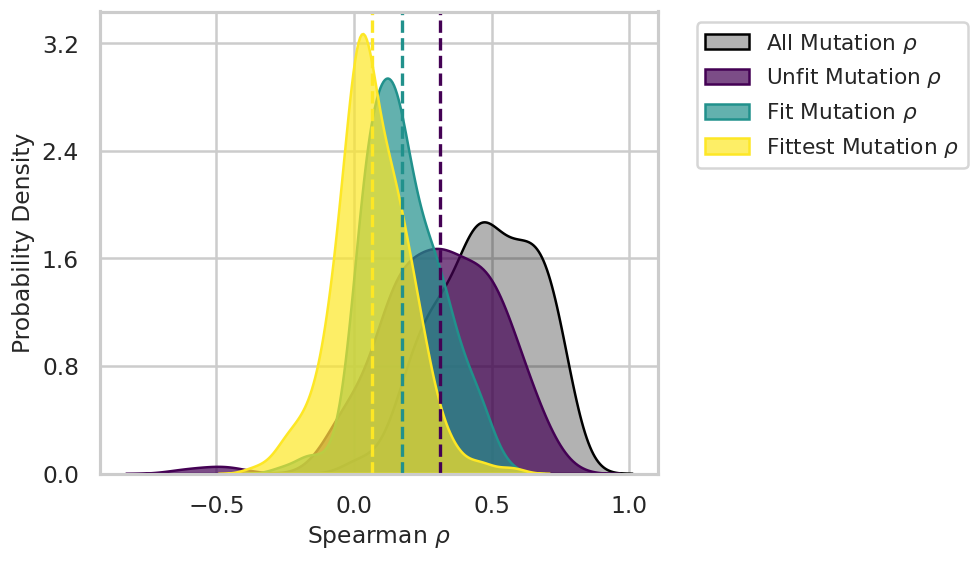

In [21]:
FIG4 = {
    "proteingym_logits_pkl": REPO_ROOT / "outputs/logits/proteingym/ESM3_sm_open_v0.both.logits.x.combined.pkl",
    "individual_csv": REPO_ROOT / "data/proteingym_data/DMS_ProteinGym_substitutions/CP2C9_HUMAN_Amorosi_2021_abundance.csv",
    "density_csv": REPO_ROOT / "outputs/csvs/figure4_fitclass_density.csv",
    "out_dir": REPO_ROOT / "images/figure4",
    "colors": list(plt.cm.viridis(np.linspace(0, 1, 3))),
}


def plot_figure4_fitclass_scatter(cfg: dict):
    pm = ProteinMutationModel(temperature=1.0)
    proteinid = "_".join(cfg["individual_csv"].name.split("_")[:2])
    pm.load_pickle(cfg["proteingym_logits_pkl"], protein_id=proteinid)
    pm.compute_entropy()
    pm.load_experiment(cfg["individual_csv"])
    pm.build_dataset()

    fit_bubble = pm.data[pm.data["DMS_score_bin"] == 1]
    fit_min = fit_bubble["exp"].min()
    fittest_min = fit_bubble["exp"].median()

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.scatter(pm.data["log_odds"], pm.data["exp"], s=2, label="unfit", color=cfg["colors"][0], alpha=0.4)
    ax.scatter(pm.data[pm.data["exp"] > fit_min]["log_odds"], pm.data[pm.data["exp"] > fit_min]["exp"], s=2, label="fit", color=cfg["colors"][1], alpha=0.4)
    ax.scatter(pm.data[pm.data["exp"] > fittest_min]["log_odds"], pm.data[pm.data["exp"] > fittest_min]["exp"], s=2, label="fittest", color=cfg["colors"][2], alpha=0.4)

    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=13, markerscale=6)
    ax.axvline(0, c="k", linestyle="--")
    ax.set_xlabel("Mutation Log-Odds", fontsize=14)
    ax.set_ylabel("Abundance", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))

    save_figure(fig, cfg["out_dir"] / "fitness_scatter", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


def plot_figure4_fitclass_density(cfg: dict):
    plt_data = pd.read_csv(cfg["density_csv"])
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.kdeplot(plt_data["all_rho"], label="All Mutation $\\rho$", fill=True, alpha=0.3, color="k", ax=ax)
    sns.kdeplot(plt_data["unfit_rho"], label="Unfit Mutation $\\rho$", fill=True, alpha=0.7, color=cfg["colors"][0], ax=ax)
    sns.kdeplot(plt_data["fit_rho"], label="Fit Mutation $\\rho$", fill=True, alpha=0.7, color=cfg["colors"][1], ax=ax)
    sns.kdeplot(plt_data["fittest_rho"], label="Fittest Mutation $\\rho$", fill=True, alpha=0.7, color=cfg["colors"][2], ax=ax)

    ax.axvline(plt_data["unfit_rho"].mean(), color=cfg["colors"][0], linestyle="--", linewidth=2)
    ax.axvline(plt_data["fit_rho"].mean(), color=cfg["colors"][1], linestyle="--", linewidth=2)
    ax.axvline(plt_data["fittest_rho"].mean(), color=cfg["colors"][2], linestyle="--", linewidth=2)

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlabel("Spearman $\\rho$", fontsize=14)
    ax.set_ylabel("Probability Density", fontsize=14)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=13)

    save_figure(fig, cfg["out_dir"] / "fitness_density", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


ensure_dir(FIG4["out_dir"])
plot_figure4_fitclass_scatter(FIG4)
plot_figure4_fitclass_density(FIG4)

## Figure 5
Directed evolution case studies. Turn panels on/off with `run_panels`.

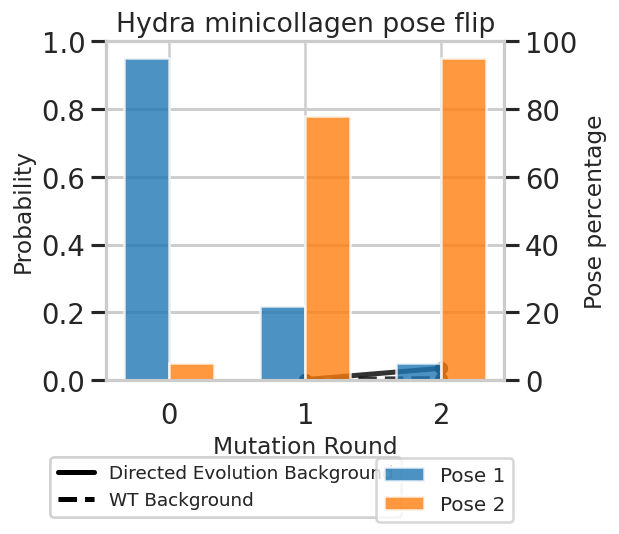

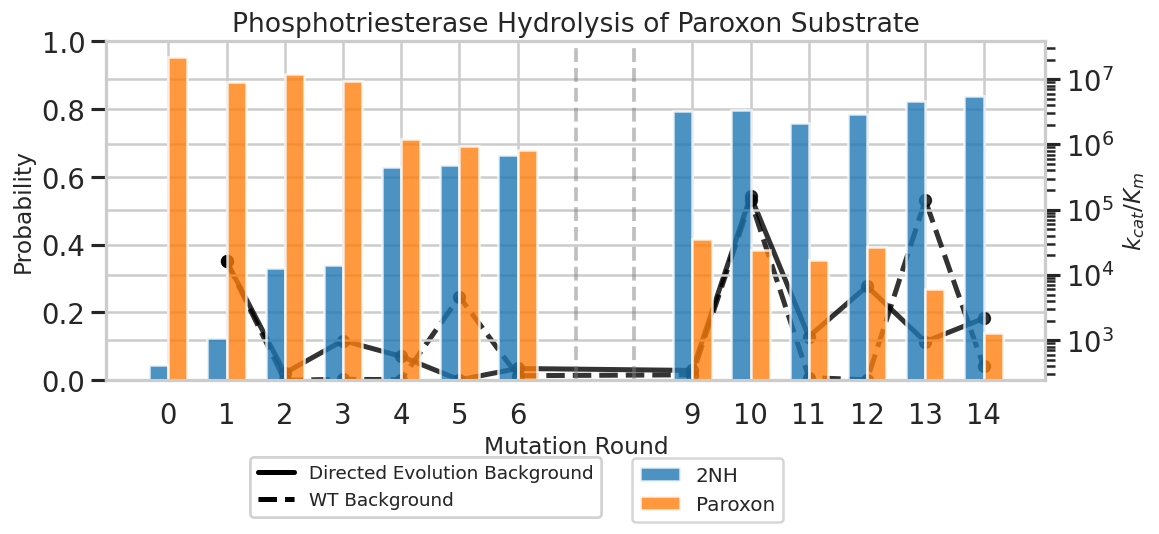

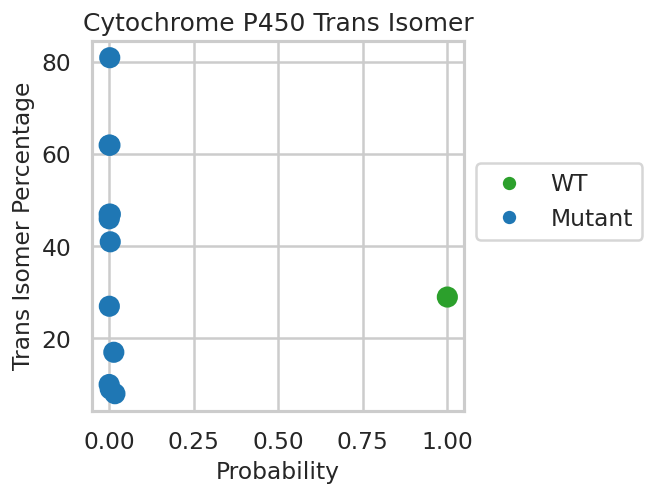

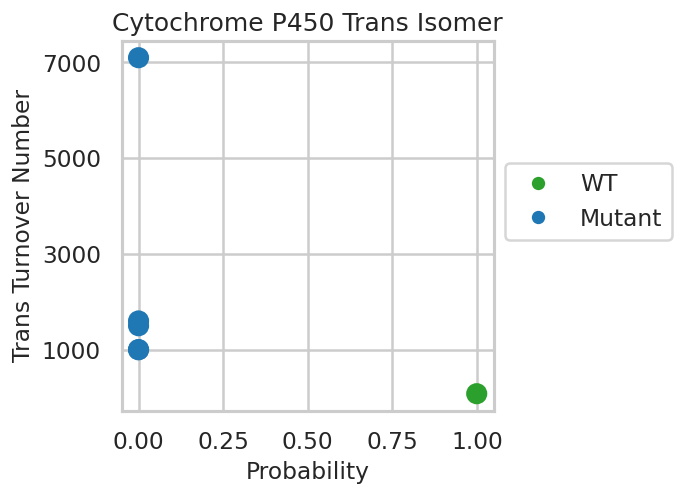

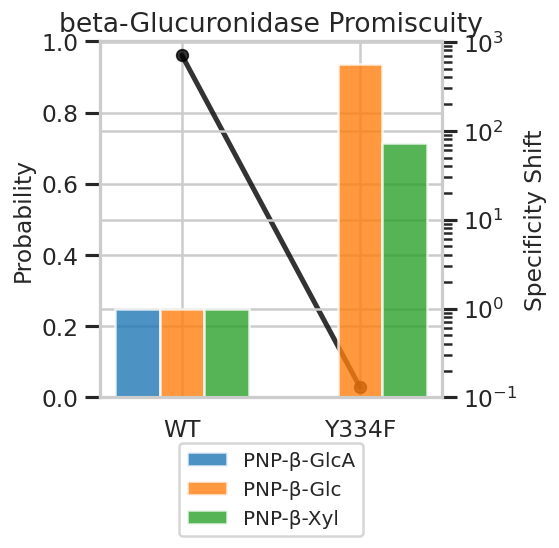

In [15]:
FIG5 = {
    "csv_dir": REPO_ROOT / "data/denovo_data/fig5_data",
    "out_dir": REPO_ROOT / "images/figure5",
    "model": "SaProt_650M_PDB",
    "run_panels": {
        "ozbek_minicollagen": True,
        "tawfik_phosphotriesterase": True,
        "arnold_trans_isomer": True,
        "arnold_ttn": True,
        "kaneko_glucuronidase": True,
    },
}


def get_fig5_groups(cfg: dict):
    csvdir = cfg["csv_dir"]
    tawfik_preds_name = [
        "OPD_BREDI.MODEL.logits.indices_254_306_274_233_172_269_272_80_111_204_130_271",
        "OPD_BREDI_H254R.MODEL.logits.indices_233_306",
        "OPD_BREDI_H254R_F306I.MODEL.logits.indices_274",
        "OPD_BREDI_H254R_F306I_I274S.MODEL.logits.indices_233",
        "OPD_BREDI_H254R_D233E_F306I_I274S.MODEL.logits.indices_172_269",
        "OPD_BREDI_H254R_D233E_F306I_I274S_T172I.MODEL.logits.indices_269",
        "OPD_BREDI_H254R_D233E_F306I_I274S_T172I_S269T_M138I_T199I.MODEL.logits.indices_272",
        "OPD_BREDI_H254R_D233E_F306I_I274S_T172I_S269T_M138I_T199I_L272M.MODEL.logits.indices_80",
        "OPD_BREDI_H254R_D233E_F306I_I274S_T172I_S269T_M138I_T199I_L272M_A80V.MODEL.logits.indices_111_204",
        "OPD_BREDI_H254R_D233E_F306I_I274S_T172I_S269T_M138I_T199I_L272M_A80V_S111R.MODEL.logits.indices_204",
        "OPD_BREDI_H254R_D233E_F306I_I274S_T172I_S269T_M138I_T199I_L272M_A80V_S111R_A204G.MODEL.logits.indices_130_271",
        "OPD_BREDI_H254R_D233E_F306I_I274S_T172I_S269T_M138I_T199I_L272M_A80V_S111R_A204G_L130V.MODEL.logits.indices_271",
    ]

    return {
        "Arnold_2012": {"csv": csvdir / "CPXB_PRIM2_Arnold_2012.csv", "preds_name": "CPXB_PRIM2.MODEL.logits.indices_182_264_329_401_438_439"},
        "Arnold_2014": {"csv": csvdir / "CPXB_PRIM2_Arnold_2014.csv", "preds_name": "CPXB_PRIM2.MODEL.logits.indices_182_264_329_401_438_439"},
        "Kaneko_2012": {"csv": csvdir / "C1F2K5_ACIC5_Kaneko_2012.csv", "preds_name": "C1F2K5_ACIC5.MODEL.logits.indices_45_292_334"},
        "full-Ozbek_2007": {"csv": csvdir / "full-Q8IT70_HYDVU_Ozbek_2007_round-order.csv", "preds_name": ["full-Q8IT70_HYDVU.MODEL.logits.indices_482", "full-Q8IT70_HYDVU_K482P.MODEL.logits.indices_472"]},
        "Tawfik_2012": {"csv": csvdir / "OPD_BREDI_Tawfik_2012_round-order.csv", "preds_name": tawfik_preds_name},
    }


def load_fig5_predictions(cfg: dict):
    pkl = REPO_ROOT / f"outputs/logits/denovo/{cfg['model']}.logits.x.denovo.pkl"
    with open(pkl, "rb") as inf:
        return pickle.load(inf)


def fig5_ozbek(cfg: dict, groups: dict, all_preds: dict):
    data = pd.read_csv(groups["full-Ozbek_2007"]["csv"])
    model = cfg["model"]
    wt_preds = all_preds[f"full-Q8IT70_HYDVU.{model}.logits.indices_472_482"]

    bar1, bar2, muts_p, muts_p_wtbackground, rounds = [], [], [], [], []
    for _, row in data.iterrows():
        rounds.append(row["round"])
        bar1.append(row["pose1"])
        bar2.append(row["pose2"])

        if row["name"] == "WT":
            muts_p.append(np.nan)
            muts_p_wtbackground.append(np.nan)
            continue

        pred_name = row["pred"].replace("MODEL", model)
        preds = all_preds[pred_name]
        _, mut_p, _, _ = pull_probs(row["mutant"], preds, pred_name)
        _, mut_p_wt, _, _ = pull_probs(row["mutant"], wt_preds, pred_name)
        muts_p.append(mut_p)
        muts_p_wtbackground.append(mut_p_wt)

    x = np.array(rounds)
    fig, ax1 = plt.subplots(figsize=(5.5, 5))
    ax1.plot(x, muts_p, color="#000000", marker="o", markersize=7, linewidth=3, linestyle="-", alpha=0.8)
    ax1.plot(x, muts_p_wtbackground, color="#000000", marker="o", markersize=7, linewidth=3, linestyle="--", alpha=0.8)
    ax1.set_ylabel("Probability", fontsize=14)
    ax1.set_ylim(0, 1)

    ax2 = ax1.twinx()
    width = 0.33
    for i, (metric, label, color) in enumerate(zip([bar1, bar2], ["Pose 1", "Pose 2"], ["#1f77b4", "#ff7f0e"])):
        ax2.bar(x + (i - 0.5) * width, metric, width, label=label, color=color, alpha=0.8)

    ax1.set_xlabel("Mutation Round", fontsize=14)
    ax2.set_ylabel("Pose percentage", fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(r) for r in x])
    ax2.set_ylim(0, 100)

    ax2.legend(bbox_to_anchor=(0.85, -0.20), loc="upper center", fontsize=12)
    style_legend = [
        Line2D([0], [0], color="black", linewidth=3, linestyle="-", label="Directed Evolution Background"),
        Line2D([0], [0], color="black", linewidth=3, linestyle="--", label="WT Background"),
    ]
    leg = ax1.legend(handles=style_legend, bbox_to_anchor=(0.3, -0.20), loc="upper center", fontsize=11)
    ax1.add_artist(leg)

    ax1.set_title("Hydra minicollagen pose flip", fontsize=16)
    fig.tight_layout()
    save_figure(fig, cfg["out_dir"] / f"Ozbek-2007_{cfg['model']}", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


def fig5_tawfik(cfg: dict, groups: dict, all_preds: dict):
    data = pd.read_csv(groups["Tawfik_2012"]["csv"])
    model = cfg["model"]
    wt_preds = all_preds[f"OPD_BREDI.{model}.logits.indices_80_111_130_172_204_233_254_269_271_272_274_306"]

    bar1, bar2, muts_p, muts_p_wtbackground, rounds = [], [], [], [], []
    for _, row in data.iterrows():
        rounds.append(row["round"])
        bar1.append(row["kcat-Km_2NH"])
        bar2.append(row["kcat-Km_Paroxon"])

        if row["name"] == "WT":
            muts_p.append(np.nan)
            muts_p_wtbackground.append(np.nan)
            continue

        pred_name = row["pred"].replace("MODEL", model)
        preds = all_preds[pred_name]
        _, mut_p, _, _ = pull_probs(row["mutant"], preds, pred_name)
        _, mut_p_wt, _, _ = pull_probs(row["mutant"], wt_preds, pred_name)
        muts_p.append(mut_p)
        muts_p_wtbackground.append(mut_p_wt)

    x = np.array(rounds)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(x, muts_p, color="#000000", marker="o", markersize=7, linewidth=3, linestyle="-", alpha=0.8)
    ax1.plot(x, muts_p_wtbackground, color="#000000", marker="o", markersize=7, linewidth=3, linestyle="--", alpha=0.8)
    ax1.set_ylabel("Probability", fontsize=14)
    ax1.set_ylim(0, 1)

    ax2 = ax1.twinx()
    width = 0.33
    for i, (metric, label, color) in enumerate(zip([bar1, bar2], ["2NH", "Paroxon"], ["#1f77b4", "#ff7f0e"])):
        ax2.bar(x + (i - 0.5) * width, metric, width, label=label, color=color, alpha=0.8)

    ax1.set_xlabel("Mutation Round", fontsize=14)
    ax2.set_ylabel("$k_{cat}/K_m$", fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(r) for r in x])
    ax2.axvline(x=7, linestyle="--", color="gray", alpha=0.5)
    ax2.axvline(x=8, linestyle="--", color="gray", alpha=0.5)
    ax2.set_yscale("log")

    ax2.legend(bbox_to_anchor=(0.64, -0.20), loc="upper center", fontsize=12)
    style_legend = [
        Line2D([0], [0], color="black", linewidth=3, linestyle="-", label="Directed Evolution Background"),
        Line2D([0], [0], color="black", linewidth=3, linestyle="--", label="WT Background"),
    ]
    leg = ax1.legend(handles=style_legend, bbox_to_anchor=(0.34, -0.20), loc="upper center", fontsize=11)
    ax1.add_artist(leg)

    ax1.set_title("Phosphotriesterase Hydrolysis of Paroxon Substrate", fontsize=16)
    fig.tight_layout()
    save_figure(fig, cfg["out_dir"] / f"Tawfik_2012_{cfg['model']}", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


def fig5_arnold_trans_isomer(cfg: dict, groups: dict, all_preds: dict):
    data = pd.read_csv(groups["Arnold_2012"]["csv"])
    preds_name = groups["Arnold_2012"]["preds_name"].replace("MODEL", cfg["model"])
    preds = all_preds[preds_name]

    plt_data = data.sort_values("trans_pct")
    wt_row = plt_data.loc[plt_data["mutant"] == "WT"].iloc[0]
    plt_data = plt_data[plt_data["mutant"] != "WT"].copy()

    probs, trans_vals, colors = [], [], []
    for _, row in plt_data.iterrows():
        _, mut_p, _, _ = pull_probs(row["mutant"], preds, preds_name)
        probs.append(mut_p)
        trans_vals.append(row["trans_pct"])
        colors.append("tab:blue")

    wt_mut = f"C401C"
    _, wt_p, _, _ = pull_probs(wt_mut, preds, preds_name)
    probs.append(wt_p)
    trans_vals.append(wt_row["trans_pct"])
    colors.append("tab:green")

    fig, ax = plt.subplots(figsize=(4, 4))
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:green", markersize=9, label="WT"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=9, label="Mutant"),
    ]
    ax.legend(handles=legend_elements, fontsize=14, bbox_to_anchor=(1.0, 0.7), loc="upper left")
    ax.set_title("Cytochrome P450 Trans Isomer", fontsize=15)
    ax.scatter(probs, trans_vals, c=colors, s=125)
    ax.set_xlabel("Probability", fontsize=14)
    ax.set_ylabel("Trans Isomer Percentage", fontsize=14)
    ax.tick_params(labelsize=14)

    save_figure(fig, cfg["out_dir"] / f"Arnold_2012_scatter_{cfg['model']}", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


def fig5_arnold_ttn(cfg: dict, groups: dict, all_preds: dict):
    data = pd.read_csv(groups["Arnold_2014"]["csv"])
    preds_name = groups["Arnold_2014"]["preds_name"].replace("MODEL", cfg["model"])
    preds = all_preds[preds_name]

    plt_data = data.sort_values("TTN")
    probs = []
    for _, row in plt_data.iterrows():
        if row["mutant"] == "WT":
            _, p, _, _ = pull_probs("C401C", preds, preds_name)
        else:
            _, p, _, _ = pull_probs(row["mutant"], preds, preds_name)
        probs.append(p)

    colors = ["tab:green" if m == "WT" else "tab:blue" for m in plt_data["mutant"]]

    fig, ax = plt.subplots(figsize=(4, 4))
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:green", markersize=9, label="WT"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=9, label="Mutant"),
    ]
    ax.legend(handles=legend_elements, fontsize=14, bbox_to_anchor=(1.0, 0.7), loc="upper left")
    ax.set_title("Cytochrome P450 Trans Isomer", fontsize=15)
    ax.scatter(probs, plt_data["TTN"], c=colors, s=125)
    ax.set_xlabel("Probability", fontsize=14)
    ax.set_ylabel("Trans Turnover Number", fontsize=14)
    ax.set_yticks([1000, 3000, 5000, 7000])
    ax.tick_params(labelsize=14)

    save_figure(fig, cfg["out_dir"] / f"Arnold_2014_scatter_{cfg['model']}", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


def fig5_kaneko(cfg: dict, groups: dict, all_preds: dict):
    data = pd.read_csv(groups["Kaneko_2012"]["csv"])
    preds_name = groups["Kaneko_2012"]["preds_name"].replace("MODEL", cfg["model"])
    preds = all_preds[preds_name]

    plt_data = data.iloc[:2, :].copy()
    wt_p, mut_p, _, _ = pull_probs("Y334F", preds, preds_name)

    width = 0.25
    metrics = ["PNP-β-GlcA_specificity-shift", "PNP-β-Glc_specificity-shift", "PNP-β-Xyl_specificity-shift"]
    labels = ["PNP-β-GlcA", "PNP-β-Glc", "PNP-β-Xyl"]
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    x = np.arange(len(plt_data))
    fig, ax1 = plt.subplots(figsize=(5, 5))
    ax1.plot(x, [wt_p, mut_p], color="#000000", marker="o", markersize=7, linewidth=3, alpha=0.8)
    ax1.set_ylabel("Probability", fontsize=14)
    ax1.set_ylim(0, 1)
    ax1.tick_params(axis="y", labelsize=14)

    ax2 = ax1.twinx()
    for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
        ax2.bar(x + (i - 1) * width, plt_data[metric].values, width, label=label, color=color, alpha=0.8)

    ax2.set_xlabel("Mutant", fontsize=14)
    ax2.set_ylabel("Specificity Shift", fontsize=14)
    ax2.set_xticks(x)
    ax1.set_xticklabels(plt_data["mutant"], fontsize=14)
    ax2.tick_params(axis="y", labelsize=14)
    ax2.set_yscale("log")
    ax2.set_ylim(0.1, None)

    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), bbox_transform=ax1.transAxes, fontsize=12)
    ax1.set_title("beta-Glucuronidase Promiscuity", fontsize=16)
    fig.tight_layout()

    save_figure(fig, cfg["out_dir"] / f"Kaneko_2012_{cfg['model']}", GLOBAL_CONFIG)
    if GLOBAL_CONFIG["show_figures"]:
        plt.show()
    else:
        plt.close(fig)


ensure_dir(FIG5["out_dir"])
fig5_groups = get_fig5_groups(FIG5)
fig5_preds = load_fig5_predictions(FIG5)

if FIG5["run_panels"]["ozbek_minicollagen"]:
    fig5_ozbek(FIG5, fig5_groups, fig5_preds)
if FIG5["run_panels"]["tawfik_phosphotriesterase"]:
    fig5_tawfik(FIG5, fig5_groups, fig5_preds)
if FIG5["run_panels"]["arnold_trans_isomer"]:
    fig5_arnold_trans_isomer(FIG5, fig5_groups, fig5_preds)
if FIG5["run_panels"]["arnold_ttn"]:
    fig5_arnold_ttn(FIG5, fig5_groups, fig5_preds)
if FIG5["run_panels"]["kaneko_glucuronidase"]:
    fig5_kaneko(FIG5, fig5_groups, fig5_preds)